<a href="https://www.kaggle.com/code/tensura3607/01-train-resnet-unet-kaggle?scriptVersionId=322971436" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Train ResNet-UNet on Kaggle

Notebook này dùng cho Kaggle. Hỗ trợ các layout dữ liệu phổ biến:

- `DATA_ROOT/images` và `DATA_ROOT/masks`
- `DATA_ROOT/train|val|test/images` và `DATA_ROOT/train|val|test/masks`
- file `.npz` có key ảnh/mask như `images` + `masks`, `x` + `y`, `image` + `mask`

Nếu dữ liệu hoặc source repo nằm ở vị trí khác, set biến môi trường `DATA_ROOT` hoặc `PROJECT_ROOT` trước khi chạy.

In [1]:
from pathlib import Path
import os
import subprocess
import sys


FALL_BACK_URL = "https://github.com/Sura3607/Automated_Abdominal_Multi-Organ_Segmentation_via_Contrastive_Learning_and_Attention_Mechanisms.git"
GITHUB_REPO_URL = os.getenv("GITHUB_REPO_URL", "").strip() or FALL_BACK_URL
GITHUB_BRANCH = os.getenv("GITHUB_BRANCH", "").strip()

try:
    import kagglehub 
except ImportError:
    print("kagglehub chưa có, đang cài đặt để upload Kaggle Model.")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])

def clone_or_pull_repo(repo_url, branch=""):
        repo_dir = Path("/kaggle/working/project_repo")
        if (repo_dir / ".git").exists():
            subprocess.check_call(["git", "-C", str(repo_dir), "fetch", "origin"])
            if branch:
                subprocess.check_call(["git", "-C", str(repo_dir), "checkout", branch])
                subprocess.check_call(["git", "-C", str(repo_dir), "pull", "--ff-only", "origin", branch])
            else:
                subprocess.check_call(["git", "-C", str(repo_dir), "pull", "--ff-only"])
        elif not repo_dir.exists():
            clone_cmd = ["git", "clone", "--depth", "1"]
            if branch:
                clone_cmd.extend(["--branch", branch])
            clone_cmd.extend([repo_url, str(repo_dir)])
            subprocess.check_call(clone_cmd)
        if not (repo_dir / "src").exists():
            raise FileNotFoundError(f"Repository was cloned, but src/ was not found: {repo_dir}")
        return repo_dir

def find_project_root():
    if GITHUB_REPO_URL:
        return clone_or_pull_repo(GITHUB_REPO_URL, GITHUB_BRANCH)

    env_root = os.getenv("PROJECT_ROOT")
    candidates = []
    if env_root:
        candidates.append(Path(env_root))
    candidates.extend([Path.cwd(), Path("/kaggle/working")])
    input_root = Path("/kaggle/input")
    if input_root.exists():
        candidates.extend(sorted(input_root.glob("*")))
    for candidate in candidates:
        if (candidate / "src").exists():
            return candidate

    raise FileNotFoundError("Không tìm thấy thư mục src. Hãy attach repo như Kaggle dataset hoặc set PROJECT_ROOT/GITHUB_REPO_URL.")

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

Cloning into '/kaggle/working/project_repo'...


PROJECT_ROOT = /kaggle/working/project_repo


In [2]:
import torch
from torch import optim

from src.models import DiceCrossEntropyLoss, ResNetUNet
from src.utils import (
    build_segmentation_dataloaders,
    count_parameters,
    evaluate_segmentation,
    fit_segmentation_model,
    get_device,
    load_checkpoint,
    set_seed,
    show_loaded_segmentation_samples,
    show_segmentation_predictions,
    upload_kaggle_model_artifact,
)

set_seed(42)

def find_data_root():
    env_root = os.getenv("DATA_ROOT")
    if env_root and Path(env_root).exists():
        return Path(env_root)
    candidates = [
        Path("/kaggle/input/synapse-processed"),
        PROJECT_ROOT / "Data" / "project_TransUNet" / "data" / "Synapse",
        PROJECT_ROOT / "data" / "Synapse",
    ]
    input_root = Path("/kaggle/input")
    if input_root.exists():
        candidates.extend(path for path in input_root.rglob("Synapse") if path.is_dir())
        candidates.extend(path.parent for path in input_root.rglob("train_npz") if path.is_dir())
    for candidate in candidates:
        if (candidate / "train_npz").exists() and (candidate / "test_vol_h5").exists():
            return candidate
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return input_root

DATA_ROOT = find_data_root()

NUM_CLASSES = int(os.getenv("NUM_CLASSES", "9"))
IMAGE_SIZE = (224, 224)
BATCH_SIZE = int(os.getenv("BATCH_SIZE", "12"))
EPOCHS = int(os.getenv("EPOCHS", "120"))
LR = float(os.getenv("LR", "1e-4"))
WEIGHT_DECAY = float(os.getenv("WEIGHT_DECAY", "1e-4"))
NUM_WORKERS = int(os.getenv("NUM_WORKERS", "2"))
EARLY_STOPPING_PATIENCE = int(os.getenv("EARLY_STOPPING_PATIENCE", "20"))
EARLY_STOPPING_MIN_DELTA = float(os.getenv("EARLY_STOPPING_MIN_DELTA", "1e-4"))
USE_PRETRAINED_ENCODER = os.getenv("USE_PRETRAINED_ENCODER", "1") == "1"
HU_WINDOW = (-125.0, 275.0) if os.getenv("USE_HU_WINDOW", "1") == "1" else None

KAGGLE_USERNAME = os.getenv("KAGGLE_USERNAME", "tensura3607")
KAGGLE_MODEL_SLUG = os.getenv("KAGGLE_MODEL_SLUG", "abdominal-multi-organ-segmentation")
KAGGLE_MODEL_FRAMEWORK = os.getenv("KAGGLE_MODEL_FRAMEWORK", "pyTorch")
KAGGLE_MODEL_VARIATION = os.getenv("KAGGLE_MODEL_VARIATION", "resnet-unet")
KAGGLE_MODEL_LICENSE = os.getenv("KAGGLE_MODEL_LICENSE", "Apache 2.0")
PUBLISH_TO_KAGGLE_MODEL = os.getenv("PUBLISH_TO_KAGGLE_MODEL", "1") == "1"
ARTIFACT_DIR = Path("/kaggle/working") / KAGGLE_USERNAME / "models" / "resnet_unet" if Path("/kaggle").exists() else PROJECT_ROOT / "artifacts" / KAGGLE_USERNAME / "resnet_unet"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
BEST_PATH = ARTIFACT_DIR / "best_resnet_unet.pt"

print(f"DATA_ROOT = {DATA_ROOT}")
print(f"ARTIFACT_DIR = {ARTIFACT_DIR}")
print(f"KAGGLE_USERNAME = {KAGGLE_USERNAME}")
print(f"KAGGLE_MODEL_HANDLE = {KAGGLE_USERNAME}/{KAGGLE_MODEL_SLUG}/{KAGGLE_MODEL_FRAMEWORK}/{KAGGLE_MODEL_VARIATION}")
print(f"PUBLISH_TO_KAGGLE_MODEL = {PUBLISH_TO_KAGGLE_MODEL}")
print(f"USE_PRETRAINED_ENCODER = {USE_PRETRAINED_ENCODER}")
print(f"BATCH_SIZE = {BATCH_SIZE}, NUM_WORKERS = {NUM_WORKERS}, EPOCHS = {EPOCHS}")
print(f"EARLY_STOPPING_PATIENCE = {EARLY_STOPPING_PATIENCE}")
print("External downloads:")
print("- kagglehub package for Kaggle Model upload")
print("- torchvision ResNet-50 ImageNet-1K weights when USE_PRETRAINED_ENCODER=1")

DATA_ROOT = /kaggle/input/datasets/tensura3607/synapse-multi-organ/Synapse
ARTIFACT_DIR = /kaggle/working/tensura3607/models/resnet_unet
KAGGLE_USERNAME = tensura3607
KAGGLE_MODEL_HANDLE = tensura3607/abdominal-multi-organ-segmentation/pyTorch/resnet-unet
PUBLISH_TO_KAGGLE_MODEL = True
USE_PRETRAINED_ENCODER = True
BATCH_SIZE = 12, NUM_WORKERS = 2, EPOCHS = 120
EARLY_STOPPING_PATIENCE = 20
External downloads:
- kagglehub package for Kaggle Model upload
- torchvision ResNet-50 ImageNet-1K weights when USE_PRETRAINED_ENCODER=1


{'train': 1866, 'val': 345, 'test': 1568}
Batch image shape: (12, 3, 224, 224)
Batch mask shape: (12, 224, 224)
Mask labels in first batch: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Train samples after loading labels: [[0, 1], [0, 1, 5], [0, 1, 5, 7]]


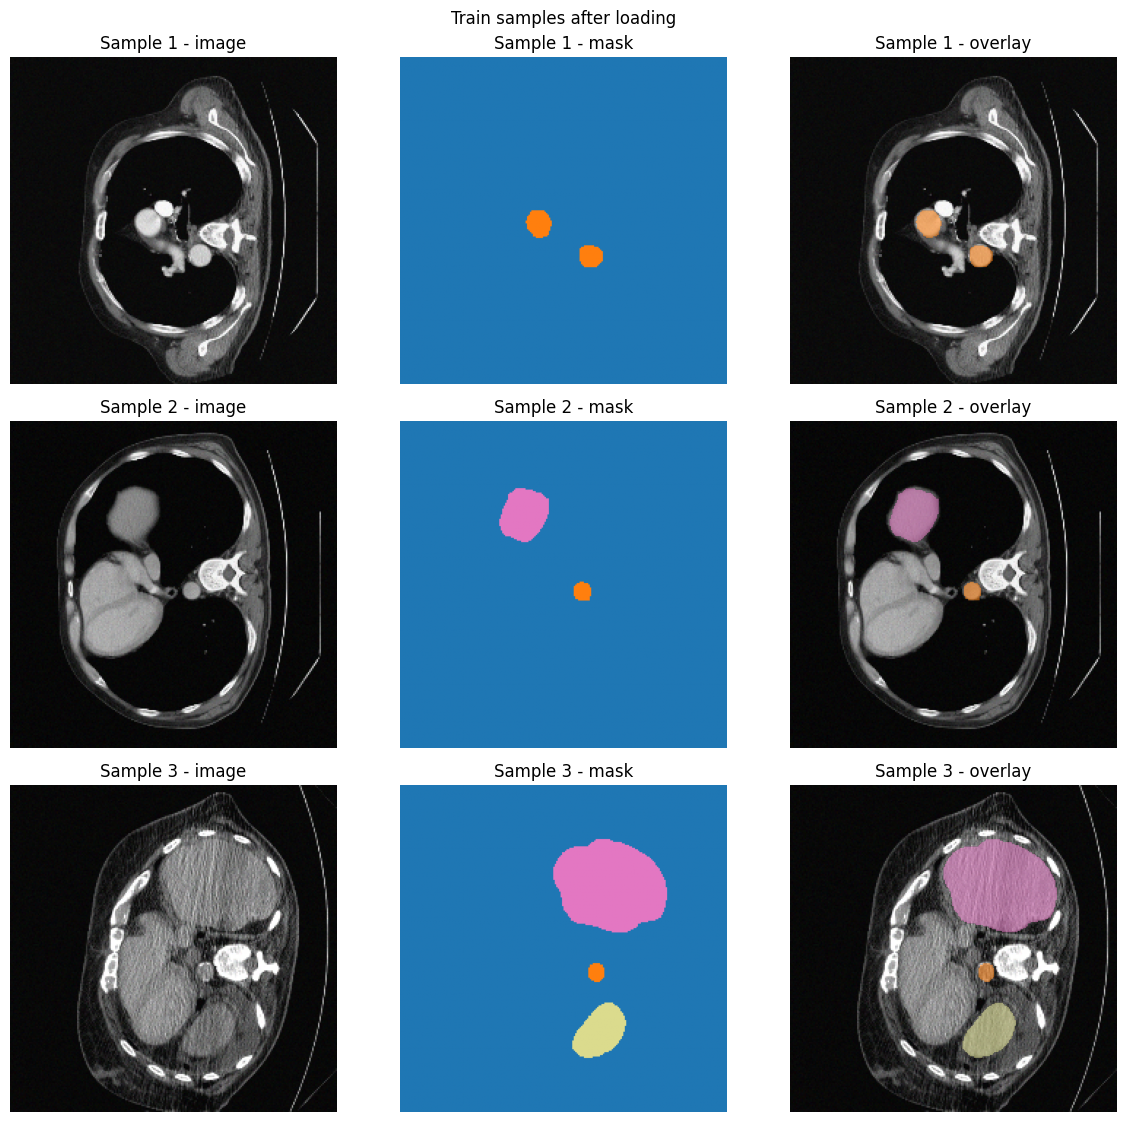

Test samples after loading labels: [[0, 5], [0, 5], [0, 5]]


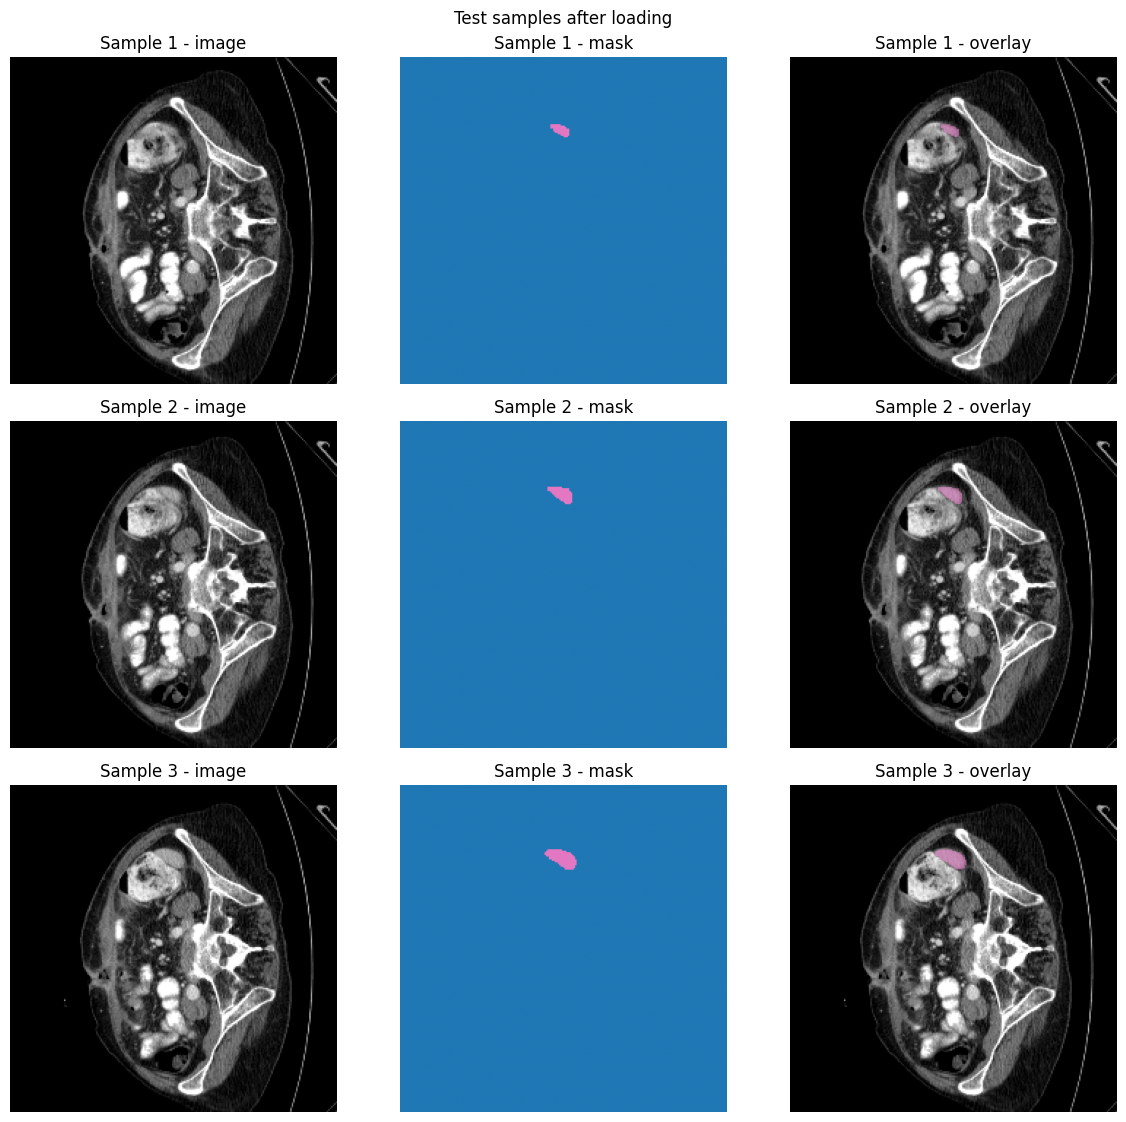

In [3]:
loaders, records = build_segmentation_dataloaders(
    data_root=DATA_ROOT,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    train_ratio=0.70,
    val_ratio=0.15,
    seed=42,
    hu_window=HU_WINDOW,
)

print({split: len(items) for split, items in records.items()})
images, masks = next(iter(loaders["train"]))
print("Batch image shape:", tuple(images.shape))
print("Batch mask shape:", tuple(masks.shape))
print("Mask labels in first batch:", torch.unique(masks).tolist())

show_loaded_segmentation_samples(
    loaders["train"],
    max_samples=3,
    num_classes=NUM_CLASSES,
    title="Train samples after loading",
)
show_loaded_segmentation_samples(
    loaders["test"],
    max_samples=3,
    num_classes=NUM_CLASSES,
    title="Test samples after loading",
)

In [4]:
device = get_device()
model = ResNetUNet(
    num_classes=NUM_CLASSES,
    in_channels=3,
    pretrained_encoder=USE_PRETRAINED_ENCODER,
).to(device)

criterion = DiceCrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

print(f"Device: {device}")
print(f"Trainable params: {count_parameters(model):,}")

history = fit_segmentation_model(
    model=model,
    loaders=loaders,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_classes=NUM_CLASSES,
    epochs=EPOCHS,
    checkpoint_path=BEST_PATH,
    use_amp=True,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    early_stopping_min_delta=EARLY_STOPPING_MIN_DELTA,
)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 188MB/s]


Device: cuda
Trainable params: 38,490,313


/kaggle/working/project_repo/src/utils.py:859: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if use_amp and device.type == "cuda" else None
/kaggle/working/project_repo/src/utils.py:754: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 001/120 | train_loss=1.2567 train_dice=0.1068 | val_loss=1.0846 val_dice=0.1122 val_iou=0.1017
Saved best checkpoint: /kaggle/working/tensura3607/models/resnet_unet/best_resnet_unet.pt
Epoch 002/120 | train_loss=0.9763 train_dice=0.1700 | val_loss=0.9044 val_dice=0.1537 val_iou=0.1192
Saved best checkpoint: /kaggle/working/tensura3607/models/resnet_unet/best_resnet_unet.pt
Epoch 003/120 | train_loss=0.7958 train_dice=0.1958 | val_loss=0.7454 val_dice=0.1589 val_iou=0.1288
Saved best checkpoint: /kaggle/working/tensura3607/models/resnet_unet/best_resnet_unet.pt
Epoch 004/120 | train_loss=0.6575 train_dice=0.2207 | val_loss=0.6271 val_dice=0.1981 val_iou=0.1563
Saved best checkpoint: /kaggle/working/tensura3607/models/resnet_unet/best_resnet_unet.pt
Epoch 005/120 | train_loss=0.5524 train_dice=0.3648 | val_loss=0.5436 val_dice=0.4213 val_iou=0.3418
Saved best checkpoint: /kaggle/working/tensura3607/models/resnet_unet/best_resnet_unet.pt
Epoch 006/120 | train_loss=0.4685 train_dice=

Test metrics
loss      : 0.3484
mean Dice : 0.8119
mean IoU  : 0.7003
pixel acc : 0.9926
Dice per class: [0.9968, 0.8747, 0.6662, 0.9226, 0.8963, 0.9479, 0.5807, 0.847, 0.7598]
IoU per class : [0.9936, 0.7773, 0.4995, 0.8562, 0.812, 0.901, 0.4091, 0.7347, 0.6127]
Saved Kaggle model artifact folder: /kaggle/working/tensura3607/models/resnet_unet
Saved Kaggle model artifact zip: /kaggle/working/tensura3607/models/resnet_unet_synapse_artifact.zip
Uploading Model https://api.kaggle.com/models/tensura3607/abdominal-multi-organ-segmentation/pyTorch/resnet-unet ...
Starting upload for file /kaggle/working/tensura3607/models/resnet_unet/best_resnet_unet.pt


Uploading: 100%|██████████| 462M/462M [00:05<00:00, 90.9MB/s]

Upload successful: /kaggle/working/tensura3607/models/resnet_unet/best_resnet_unet.pt (441MB)
Starting upload for file /kaggle/working/tensura3607/models/resnet_unet/test_metrics.json



Uploading: 100%|██████████| 620/620 [00:00<00:00, 1.61kB/s]

Upload successful: /kaggle/working/tensura3607/models/resnet_unet/test_metrics.json (620B)
Starting upload for file /kaggle/working/tensura3607/models/resnet_unet/model_info.json



Uploading: 100%|██████████| 1.13k/1.13k [00:00<00:00, 2.92kB/s]

Upload successful: /kaggle/working/tensura3607/models/resnet_unet/model_info.json (1KB)


Your model instance version has been created.
Files are being processed...
See at: https://api.kaggle.com/models/tensura3607/abdominal-multi-organ-segmentation/pyTorch/resnet-unet
Uploaded new Kaggle Model version: https://www.kaggle.com/models/tensura3607/abdominal-multi-organ-segmentation/pyTorch/resnet-unet


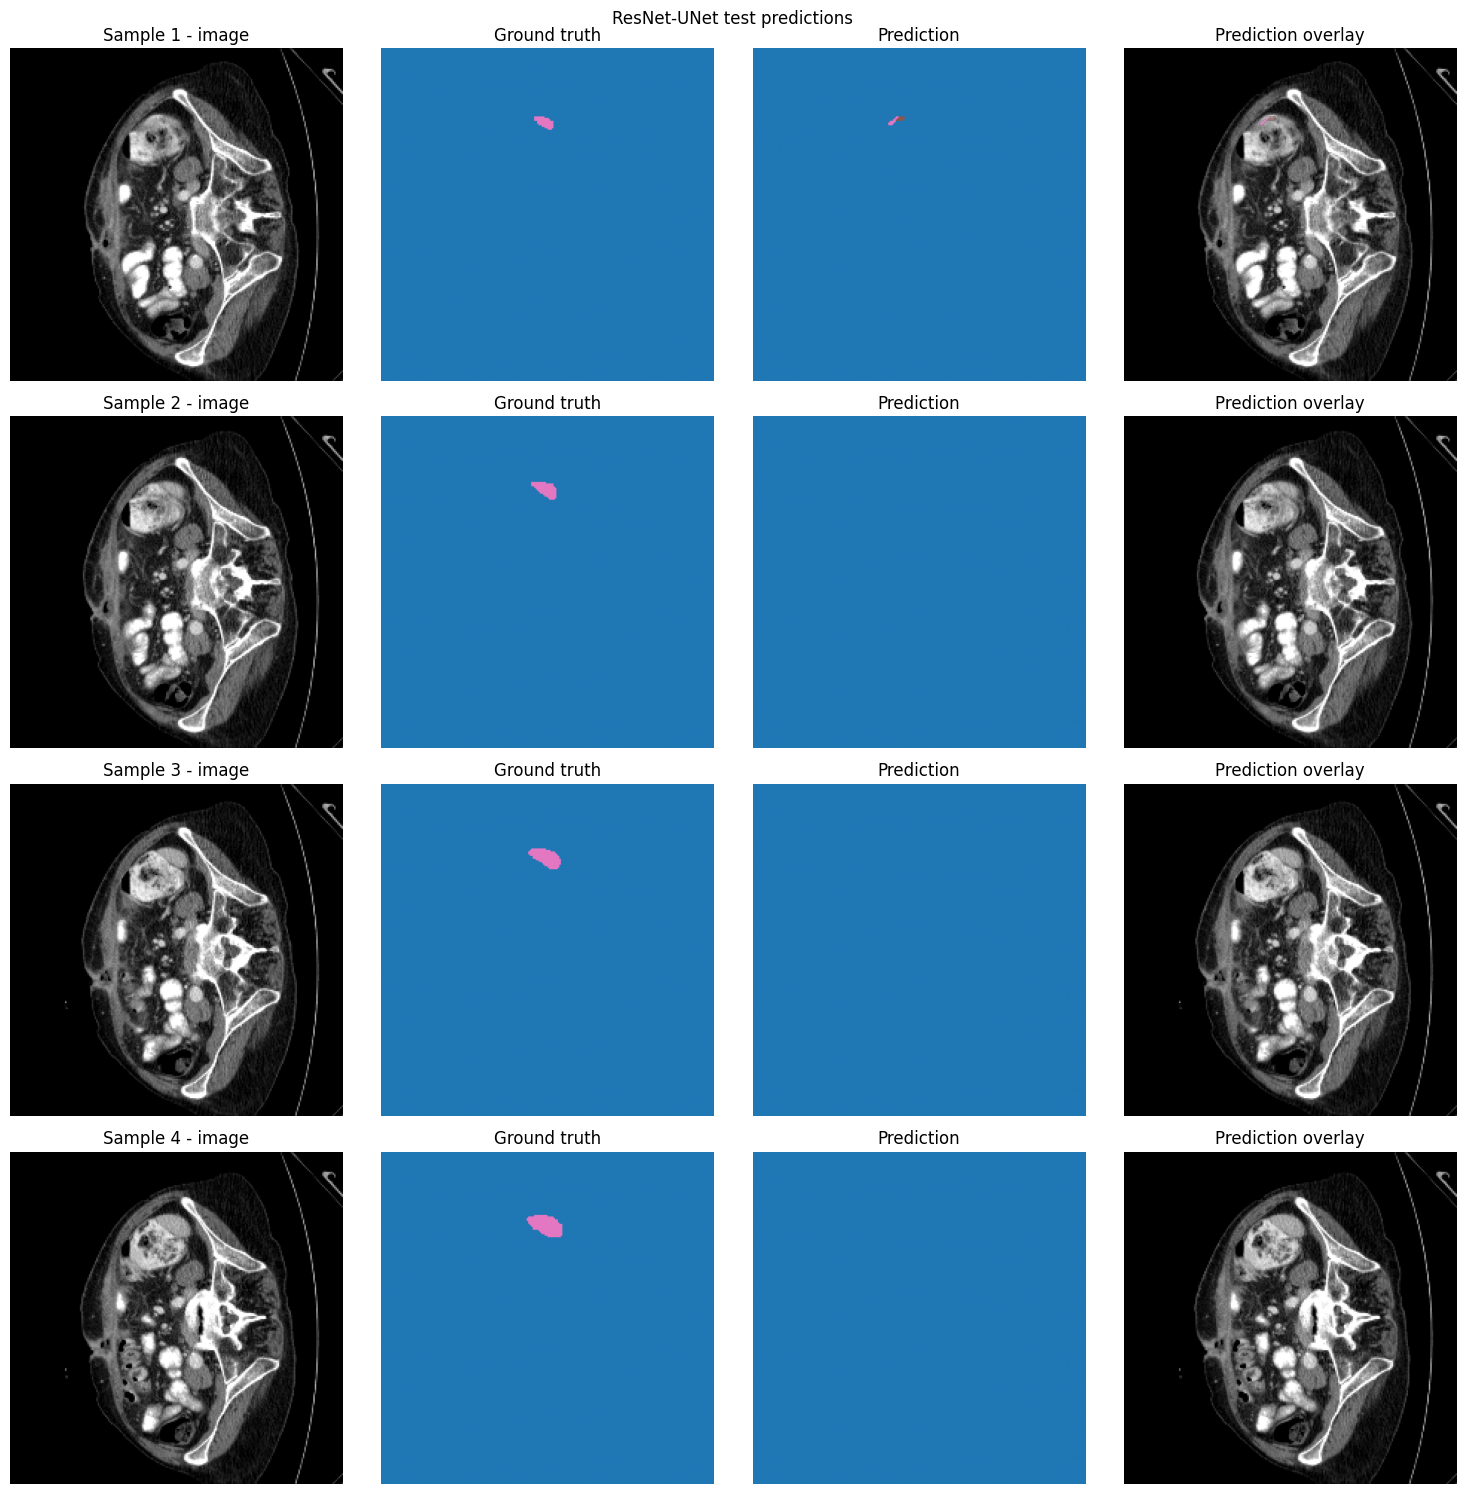

In [5]:
load_checkpoint(BEST_PATH, model=model, map_location=device)
test_metrics = evaluate_segmentation(model, loaders["test"], criterion, device, NUM_CLASSES)

print("Test metrics")
print(f"loss      : {test_metrics['loss']:.4f}")
print(f"mean Dice : {test_metrics['dice_mean']:.4f}")
print(f"mean IoU  : {test_metrics['iou_mean']:.4f}")
print(f"pixel acc : {test_metrics['pixel_acc']:.4f}")
print("Dice per class:", [round(x, 4) for x in test_metrics["dice_per_class"]])
print("IoU per class :", [round(x, 4) for x in test_metrics["iou_per_class"]])

import json
import shutil

metrics_path = ARTIFACT_DIR / "test_metrics.json"
metrics_path.write_text(json.dumps(test_metrics, indent=2), encoding="utf-8")

model_info = {
    "owner": KAGGLE_USERNAME,
    "model_name": "resnet_unet_synapse",
    "architecture": "ResNetUNet",
    "num_classes": NUM_CLASSES,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs_requested": EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "pretrained_encoder": USE_PRETRAINED_ENCODER,
    "checkpoint": str(BEST_PATH),
    "data_root": str(DATA_ROOT),
    "test_metrics": test_metrics,
}
(ARTIFACT_DIR / "model_info.json").write_text(json.dumps(model_info, indent=2), encoding="utf-8")
archive_path = shutil.make_archive(str(ARTIFACT_DIR.parent / "resnet_unet_synapse_artifact"), "zip", ARTIFACT_DIR)
print(f"Saved Kaggle model artifact folder: {ARTIFACT_DIR}")
print(f"Saved Kaggle model artifact zip: {archive_path}")

if PUBLISH_TO_KAGGLE_MODEL:
    version_notes = (
        f"ResNet-UNet Synapse checkpoint. "
        f"Test Dice={test_metrics['dice_mean']:.4f}, IoU={test_metrics['iou_mean']:.4f}."
    )
    uploaded_handle = upload_kaggle_model_artifact(
        local_model_dir=ARTIFACT_DIR,
        owner=KAGGLE_USERNAME,
        model_slug=KAGGLE_MODEL_SLUG,
        framework=KAGGLE_MODEL_FRAMEWORK,
        variation=KAGGLE_MODEL_VARIATION,
        version_notes=version_notes,
        license_name=KAGGLE_MODEL_LICENSE,
    )
    print(f"Uploaded new Kaggle Model version: https://www.kaggle.com/models/{uploaded_handle}")
else:
    print("Skipped Kaggle Model upload because PUBLISH_TO_KAGGLE_MODEL=0")

show_segmentation_predictions(
    model=model,
    loader=loaders["test"],
    device=device,
    max_samples=4,
    num_classes=NUM_CLASSES,
    title="ResNet-UNet test predictions",
)